# South West Constraint Model

This notebook models transmission constraint risk in the South West
using Balancing Mechanism (BOALF) data.

Constraint events are defined using a data-driven threshold based on
regional BM activity. A logistic regression model is then used to
identify the relationship between constraint risk, wind generation,
and demand.

Key result:
Constraint risk is higher during periods of low wind generation,
indicating import-driven transmission stress.

In [1]:
# =========================
# LOAD DATA (RESET STATE)
# =========================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


df = pd.read_csv("../data/processed/modelling_dataset.csv")

print("df shape:", df.shape)

df shape: (17479, 5)


## Build constraint event from BOALF

In [2]:
# ── LOAD ──────────────────────────────────────────────────────────────
df_boalf = pd.read_csv("../data/raw/boalf_sw_2022.csv")
df_boalf['settlementDate'] = pd.to_datetime(df_boalf['settlementDate'])

# ── ACCEPTED VOLUME PER ACCEPTANCE ────────────────────────────────────
df_boalf['accepted_mw']     = df_boalf['levelTo'] - df_boalf['levelFrom']
df_boalf['accepted_mw_abs'] = df_boalf['accepted_mw'].abs()
df_boalf['sp_key'] = (
    df_boalf['settlementDate'].dt.strftime('%Y-%m-%d') + '_' +
    df_boalf['settlementPeriodFrom'].astype(str)
)

# ── AGGREGATE TO SP ───────────────────────────────────────────────────
sp_volume = (
    df_boalf.groupby(['sp_key', 'settlementDate', 'settlementPeriodFrom'])
    .agg(
        total_accepted_mw = ('accepted_mw_abs', 'sum'),
        n_acceptances     = ('acceptanceNumber', 'nunique'),
        n_bmus_active     = ('nationalGridBmUnit', 'nunique'),
    )
    .reset_index()
)

# ── FULL SP INDEX — fill zero-activity periods ─────────────────────────
all_dates = pd.date_range('2022-01-01', '2022-12-31', freq='D')
full_index = pd.DataFrame([
    {
        'settlementDate':       d,
        'settlementPeriodFrom': sp,
        'sp_key':               f"{d.strftime('%Y-%m-%d')}_{sp}"
    }
    for d in all_dates for sp in range(1, 49)
])

df_sp = full_index.merge(
    sp_volume,
    on=['sp_key', 'settlementDate', 'settlementPeriodFrom'],
    how='left'
)
df_sp[['total_accepted_mw', 'n_acceptances', 'n_bmus_active']] = (
    df_sp[['total_accepted_mw', 'n_acceptances', 'n_bmus_active']].fillna(0)
)

# ── 75th PERCENTILE THRESHOLD ─────────────────────────────────────────
# Computed ONLY over SPs with non-zero activity
# (including zeros would make the threshold trivially low
#  since ~half of SPs have no BM action at all)
active_sps   = df_sp[df_sp['total_accepted_mw'] > 0]['total_accepted_mw']
p75_active   = active_sps.quantile(0.75)

# Also compute over ALL SPs for comparison
p75_all      = df_sp['total_accepted_mw'].quantile(0.75)

print(f"75th percentile (active SPs only): {p75_active:.1f} MW")
print(f"75th percentile (all SPs):         {p75_all:.1f} MW")
print(f"\nActive SPs:    {len(active_sps):,} / {len(df_sp):,}  ({len(active_sps)/len(df_sp):.1%})")

# Use active-SP percentile as the threshold — more meaningful
THRESHOLD_MW = p75_active

# ── BUILD TARGET VARIABLE ─────────────────────────────────────────────
df_sp['constraint_event'] = (df_sp['total_accepted_mw'] > THRESHOLD_MW).astype(int)

# ── EVENT RATE CHECK ──────────────────────────────────────────────────
n_events    = df_sp['constraint_event'].sum()
n_total     = len(df_sp)
event_rate  = df_sp['constraint_event'].mean()

print(f"\n── Target variable summary ───────────────────────────────")
print(f"  Threshold (p75 active):  {THRESHOLD_MW:.1f} MW")
print(f"  Constraint events:       {n_events:,}")
print(f"  Non-events:              {n_total - n_events:,}")
print(f"  Event rate:              {event_rate:.1%}")
print(f"\n  Distribution check (should be ~25% of active SPs):")
print(f"  Events / active SPs:     {n_events / len(active_sps):.1%}")

print(f"\n── Volume distribution ───────────────────────────────────")
print(df_sp['total_accepted_mw'].describe(percentiles=[.25, .5, .75, .9, .95]).round(1))

# ── SAVE ──────────────────────────────────────────────────────────────
df_sp['settlementDate'] = df_sp['settlementDate'].dt.strftime('%Y-%m-%d')
df_sp.to_csv("../data/sw_constraint_events_2022.csv", index=False)
print(f"\nSaved → data/sw_constraint_events_2022.csv")
print(f"Threshold stored: p75 = {THRESHOLD_MW:.1f} MW — record this for your README")

75th percentile (active SPs only): 34.0 MW
75th percentile (all SPs):         0.0 MW

Active SPs:    2,254 / 17,520  (12.9%)

── Target variable summary ───────────────────────────────
  Threshold (p75 active):  34.0 MW
  Constraint events:       550
  Non-events:              16,970
  Event rate:              3.1%

  Distribution check (should be ~25% of active SPs):
  Events / active SPs:     24.4%

── Volume distribution ───────────────────────────────────
count    17520.0
mean         3.2
std         10.9
min          0.0
25%          0.0
50%          0.0
75%          0.0
90%         11.0
95%         24.0
max        185.0
Name: total_accepted_mw, dtype: float64

Saved → data/sw_constraint_events_2022.csv
Threshold stored: p75 = 34.0 MW — record this for your README


## Merge with modelling dataset

Constraint events are defined as settlement periods where total accepted
Balancing Mechanism volume in the South West exceeds 34 MW.

This threshold corresponds to the 75th percentile of non-zero (active)
settlement periods in 2022. As only ~13% of periods exhibit any SW BM activity,
this definition results in constraint events occurring in ~3% of all periods.

In [3]:
# =========================
# MERGE SW CONSTRAINT EVENT
# =========================

df_sp = pd.read_csv("../data/sw_constraint_events_2022.csv")

df_sp['sp_key'] = (
    pd.to_datetime(df_sp['settlementDate']).dt.strftime('%Y-%m-%d') + "_" +
    df_sp['settlementPeriodFrom'].astype(int).astype(str)
)

df['sp_key'] = (
    pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d') + "_" +
    df['sp'].astype(int).astype(str)
)

df = df.merge(
    df_sp[['sp_key', 'constraint_event']],
    on='sp_key',
    how='left'
)

df['constraint_event'] = df['constraint_event'].fillna(0)

print("Event rate:", df['constraint_event'].mean())


Event rate: 0.03129469649293438


In [4]:
# =========================
# PREP DATA
# =========================

# Interaction term (critical)
df['interaction'] = df['wind_mw'] * df['sw_demand_mw']

# Features
X = df[['wind_mw', 'sw_demand_mw', 'interaction']]

# Add constant
X = sm.add_constant(X)

# Target
y = df['constraint_event']

print("Event rate:", y.mean())
print("Rows:", len(df))

Event rate: 0.03129469649293438
Rows: 17479


## Wind and constraint risk

In [5]:
# =========================
# FIT LOGIT MODEL
# =========================

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.136252
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       constraint_event   No. Observations:                17479
Model:                          Logit   Df Residuals:                    17475
Method:                           MLE   Df Model:                            3
Date:                Tue, 05 May 2026   Pseudo R-squ.:                 0.02127
Time:                        15:49:44   Log-Likelihood:                -2381.6
converged:                       True   LL-Null:                       -2433.3
Covariance Type:            nonrobust   LLR p-value:                 2.696e-22
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.8244      0.354    -13.627      0.000      -5.518      -4.130
wind_mw      -6.051e-05

## Analyse wind relationship

In [6]:
# =========================
# FINAL WIND CURVE (SW)
# =========================



# Bin wind
df['wind_bucket'] = pd.qcut(df['wind_mw'], 20, duplicates='drop')

curve = (
    df.groupby('wind_bucket', observed=True)['constraint_event']
    .agg(['mean', 'count'])
    .reset_index()
)

curve['wind_mid'] = curve['wind_bucket'].apply(lambda x: x.mid)
curve = curve.sort_values('wind_mid')

# Remove very low-sample bins
curve = curve[curve['count'] > 50]

# Light smoothing
curve['prob_smooth'] = curve['mean'].rolling(3, center=True).mean()

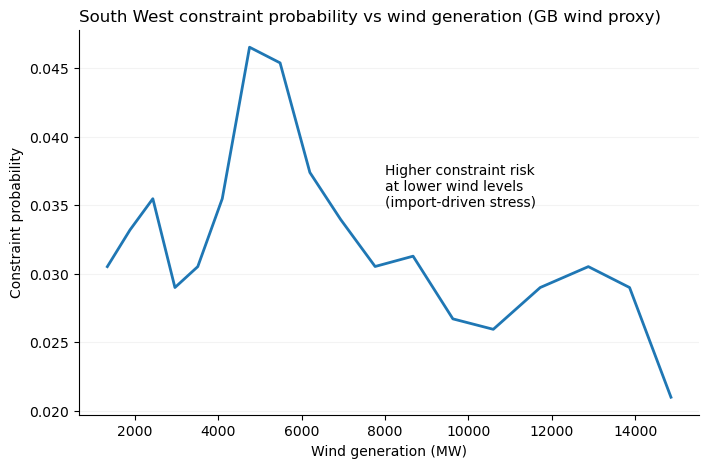

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    curve['wind_mid'],
    curve['prob_smooth'],
    linewidth=2
)

# Labels
plt.xlabel("Wind generation (MW)")
plt.ylabel("Constraint probability")

plt.title("South West constraint probability vs wind generation (GB wind proxy)", loc='left')

# Annotation (THIS is key)
plt.text(
    x=8000,
    y=curve['prob_smooth'].max()*0.75,
    s="Higher constraint risk\nat lower wind levels\n(import-driven stress)",
    fontsize=10
)

# Minimal style
plt.grid(axis='y', alpha=0.15)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

Constraint risk is highest at low wind levels, consistent with increased
reliance on imported power and resulting transmission loading.

### Sanity Checks

In [8]:
df[['constraint_event', 'wind_mw']].corr()

,constraint_event,wind_mw
constraint_event,1.000000,-0.023222
wind_mw,-0.023222,1.000000


In [9]:
df.groupby('constraint_event')['wind_mw'].mean()

constraint_event
0.0    7351.233769
1.0    6727.172432
Name: wind_mw, dtype: float64

## Interpretation

Constraint events occur in ~3% of settlement periods overall.

In contrast to system-level behaviour, constraint risk in the South West
is higher during periods of low wind generation. This suggests that
constraints are driven by import requirements rather than excess generation.

When wind output is low, the region relies more heavily on imported power,
increasing loading on inbound transmission circuits and raising the
likelihood of constraint intervention.

This highlights the importance of regional analysis, as system-level
aggregation can obscure local network dynamics.

The model indicates that South West demand is a statistically significant
driver of constraint risk, while wind generation is not a significant predictor
in this regional context.